# Flood Wall Simulations — Lao PDR

This notebook simulates the effect of building floodwalls in five Laotian cities by increasing the effective distance to rivers in the geospatial damage model.

**Three scenarios:**
1. **No wall (baseline):** Original distance-to-river values
2. **Intermediate wall:** Distance-to-river set to the **median** value across the Laos prediction grid
3. **Full wall:** Distance-to-river set to the **maximum** value across the Laos prediction grid

**Cities:** Luang Prabang, Vientiane, Savannakhet, Pakse, Attapeu

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pyprojroot import here
sys.path.insert(0, str(here()))
from os.path import exists

import pandas as pd
import numpy as np
import pymc as pm
import pytensor
import pytensor.tensor as pt
import matplotlib.pyplot as plt
import arviz as az
import xarray as xr
import pathlib

from laos_gggi.model import add_data, compute_center
from laos_gggi.plotting import configure_plot_style
from laos_gggi.data_functions import load_shapefile
from sklearn.preprocessing import StandardScaler as Standardize
from pymc.model.transform.optimization import freeze_dims_and_data
from scipy import interpolate
from cycler import cycler

In [3]:
# Paths
GEO_MODEL_DIR = here('notebooks/geo_damage_model')
PRETRAINED_IDATA_DIR = here('notebooks/final_paper/idata')
IDATA_DIR = here('notebooks/policy_note/idata')
FIGURES_DIR = here('notebooks/policy_note/figures')

# Style
OECD_colors = ["#002F6C", "#7FA8D9", "#006BB6", "#00AACC", "#82D2E3"]
OECD_cycler = cycler(color=OECD_colors)

config = {
    'figure.figsize': (14, 4),
    'figure.constrained_layout.use': True,
    'figure.facecolor': 'w',
    'axes.grid': False,
    'grid.linewidth': 0.5,
    'grid.linestyle': '--',
    'axes.spines.top': False,
    'axes.spines.bottom': False,
    'axes.spines.left': False,
    'axes.spines.right': False,
    'axes.prop_cycle': OECD_cycler,
}
plt.rcParams.update(config)

# Constants
WALL_CITIES = ['Attapeu','Vientiane',  'Pakse' ]
PREDICTION_YEARS = ["2030-01-01"]
SCENARIO_COLORS = {"No wall": "#002F6C", "Intermediate wall": "#006BB6", "Full wall": "#82D2E3"}
SEED = sum(list(map(ord, 'climate_bayes')))
rng = np.random.default_rng(SEED)
floatX = pytensor.config.floatX

# Section 1: Load Pre-trained Posteriors

In [4]:
# SEA countries used for training
laos_neighboors = ["KHM", "THA", "LAO", "VNM"]

# Load pre-trained model idatas from final_paper/idata/
# Event model (HSGP geospatial): generated by 05b_geo_model_laos_neigh.ipynb
event_idata = az.from_netcdf(PRETRAINED_IDATA_DIR / "sea_geo_model.idata")

# Damage model: generated by damage modeling pipeline
damage_idata = az.from_netcdf(PRETRAINED_IDATA_DIR / "dmg_5_2025_usd_new_b.nc")

# Rename variables to avoid conflicts when merging (same as 04_b_damage_curves_lao.ipynb)
damage_idata = damage_idata.rename({
    "country_loc": "country_loc_damage",
    "country_scale": "country_scale_damage",
    "country_offset": "country_offset_damage",
    "country_effect": "country_effect_damage",
    "beta": "beta_damage",
    "beta_GY": "beta_GY_damage",
    "mixture": "mixture_damage",
    "alpha_X": "alpha_X_damage",
    "latent_iso": "latent_iso_damage",
    "phi": "phi_damage",
    "phi_climatological_disasters": "phi_climatological_disasters_damage",
    "phi_hydrological_disasters": "phi_hydrological_disasters_damage",
    "rho": "rho_damage",
    "sigma_X": "sigma_X_damage",
    "theta": "theta_Damage",
    "p_zero": "p_zero_damage",
    "mu": "mu_damage",
})

# Prepare damage posterior: drop mu_damage and obs_idx, then rename 'feature' dim
# to 'features_damages' to avoid collision with event model's 'feature' dim (8 values)
damage_posterior = damage_idata.posterior.drop_vars(['mu_damage']).drop_dims('obs_idx')
damage_posterior = damage_posterior.rename({'feature': 'features_damages'})

# Prepare event posterior: drop obs_idx to remove obs-indexed Deterministics
# (HSGP_component, etc.) which have training grid size (30030) != prediction grid (47893)
event_posterior = event_idata.sel(ISO=laos_neighboors).posterior
if 'obs_idx' in event_posterior.dims:
    event_posterior = event_posterior.drop_dims('obs_idx')

# Merge posteriors (event + damage) — only parameter-level variables remain
merged_posteriors = xr.merge([
    damage_posterior,
    event_posterior,
])

# Section 2: Load & Prepare Prediction Grid

In [5]:
# Grid columns to load
grid_cols = ['long', 'lat', 'distance_to_river', 'log_distance_to_river',
             'log_distance_to_coastline', 'geometry', 'ISO',
             'log_distance_to_river__standardized', 'log_distance_to_coastline__standardized']

# Load datasets
sea_point_grid = pd.read_csv(here("data/sea_point_grid.csv"), index_col=0)[grid_cols]
laos_point_grid = pd.read_csv(here("data/laos_point_grid.csv"), index_col=0)[grid_cols]
sea_df = pd.read_csv(here("data/sea.csv"), index_col=0)
sea_df_stand = pd.read_csv(here("data/sea_df_stand.csv"), index_col=0)
damage_df_stand = pd.read_csv(here("data/damage_df_stand.csv"), index_col=0)
damage_df_stand["Population"] = damage_df_stand["Population"] * 1e6

# Load predictions
predictions = pd.read_csv(here("data/climate_forecast.csv")).rename(columns={"time": "Start_Year"})
predictions["ISO"] = "LAO"

# Select years
predictions_short = predictions.query('Start_Year in @PREDICTION_YEARS')

# Create grid point number and merge
laos_point_grid = laos_point_grid.reset_index().rename(columns={"index": "point_number"})
pred_df = pd.merge(laos_point_grid, predictions_short, left_on="ISO", right_on="ISO", how="left")

# Derived features
pred_df["population_density"] = pred_df["Population"] / 236800
pred_df["log_population_density"] = np.log(pred_df["population_density"])
pred_df["log_gdp_per_cap"] = np.log(pred_df["gdp_per_cap"])

# Load city locations
cities_loc = pd.read_csv(here("data/cites_loc.csv"), index_col=0)
cities_loc

,lat,long,point_number
Vientiane,17.979945,102.638469,16711
Luang Prabang,19.893911,102.126397,32680
Savannakhet,16.560600,104.762620,10878
Pakse,15.119750,105.805731,4002
Attapeu,14.818676,106.829875,2590


In [6]:
# === Damage features (country-level, matching dmg_5_2025_usd_new_b.nc) ===
# Feature names used by the damage model (same as in 04_b_damage_curves_lao.ipynb)
damage_features_base = ['ln_population_density', 'ln_gdp_pc', 'precip_deviation', 'co2', 'population']
# d_* prefix avoids column collision with event standardizer for overlapping features
# (precip_deviation__standardized and co2__standardized exist in both)
damage_features_base_d = ['d_' + x for x in damage_features_base]
damage_features_d_stand = [x + "__standardized" for x in damage_features_base_d]

# Create damage feature columns in pred_df using the canonical names
pred_df["ln_population_density"] = np.log(pred_df["population_density"])
pred_df["ln_gdp_pc"] = np.log(pred_df["gdp_per_cap"])
pred_df["population"] = pred_df["Population"]

# Build df_damage_fit with the same column names as the reference notebooks use for fitting
# damage_df_stand has different column names (log_population_density, log_gdp_per_cap, Population)
df_damage_fit = damage_df_stand.rename(columns={
    'log_population_density': 'ln_population_density',
    'log_gdp_per_cap': 'ln_gdp_pc',
    'Population': 'population',
})

# Standardize event features (fitted on SEA training data)
cols_to_stand = ['Population', 'dev_ocean_temp', 'co2', 'log_population_density',
                 'log_gdp_per_cap', 'precip_deviation']
cols_to_stand_stand = [x + "__standardized" for x in cols_to_stand]
cols_not_stand = ['ISO', 'Start_Year', 'lat', 'long', 'geometry', 'point_number',
                  'log_distance_to_river__standardized', 'log_distance_to_coastline__standardized']

transformer_stand_ = Standardize().fit(sea_df[cols_to_stand])
pred_df_stand = transformer_stand_.transform(pred_df[cols_to_stand])
pred_df_stand = pd.DataFrame(pred_df_stand, columns=cols_to_stand_stand)
pred_df_stand = pd.merge(pred_df_stand, pred_df[cols_not_stand], left_index=True, right_index=True, how="left")

# Standardize damage features (fit on training data with canonical names,
# transform prediction data with same names, then rename output to d_* prefix)
transformer_stand__damage = Standardize().fit(df_damage_fit[damage_features_base])
pred_df_stand_damage = pd.DataFrame(
    transformer_stand__damage.transform(pred_df[damage_features_base]),
    columns=damage_features_d_stand,  # d_*__standardized to avoid collision
    index=pred_df.index,
)
pred_df_stand = pd.merge(pred_df_stand, pred_df_stand_damage, left_index=True, right_index=True, how="left")

# Center lat/long using SEA bounds
sea_center = {}
for x in ["lat", "long"]:
    sea_center[x] = (sea_df[x].max() + sea_df[x].min()) / 2
    pred_df_stand[x + "_centered"] = pred_df_stand[x] - sea_center[x]

# Split into per-year DataFrames
pred_df_stand_dict = {}
for year in pred_df_stand["Start_Year"].unique():
    pred_df_stand_dict[year] = pred_df_stand.query('Start_Year == @year').copy()

In [7]:
# Extract coordinate values from merged posteriors to ensure exact match
ISO_coords = list(merged_posteriors.coords['ISO'].values)
iso_coords = list(merged_posteriors.coords['iso'].values)
disaster_coords = list(merged_posteriors.coords['disaster'].values)
feature_coords = list(merged_posteriors.coords['feature'].values)
features_damages_coords = list(merged_posteriors.coords['features_damages'].values)
gp_feature_coords = list(merged_posteriors.coords['gp_feature'].values)

# Event features: 8 features matching 'feature' dim in event posterior
event_features = list(feature_coords)

# Damage features: use d_*__standardized column names from pred_df_stand
# (d_* prefix avoids collision with event standardizer's overlapping columns)
# The posterior's features_damages coord has raw names; our model uses these column names instead
damage_features = damage_features_d_stand

# Verify damage feature columns exist in prediction DataFrame
ref_df_check = pred_df_stand_dict[PREDICTION_YEARS[0]]
for f in damage_features:
    assert f in ref_df_check.columns, f"Missing damage feature column: {f}"

# GP features
gp_features = ["lat", "long"]

# Index lookups
ISO_to_idx = {name: idx for idx, name in enumerate(ISO_coords)}
iso_to_idx = {name: idx for idx, name in enumerate(iso_coords)}
disaster_to_idx = {name: idx for idx, name in enumerate(disaster_coords)}

ISO_idx_laos = ISO_to_idx['LAO']
iso_idx_laos = iso_to_idx['LAO']

# Determine hydro disaster index
hydro_key = [k for k in disaster_to_idx if 'hydro' in k.lower()]
assert len(hydro_key) == 1, f"Expected one hydro disaster, found: {hydro_key}"
hydro_idx = disaster_to_idx[hydro_key[0]]

# Obs idx and years
obs_idx = np.arange(len(pred_df_stand_dict[PREDICTION_YEARS[0]]))
years = pred_df_stand["Start_Year"].unique()

coords_predictions = {
    "obs_idx": obs_idx,
    "ISO": ISO_coords,
    "iso": iso_coords,
    "disaster": disaster_coords,
    "feature": feature_coords,
    "features_damages": damage_features,  # d_*__standardized names matching DataFrame columns
    "gp_feature": gp_feature_coords,
}

# Section 3: Locate Cities & Compute Wall Distance Values

In [8]:
# Find nearest grid points for each city
ref_df = pred_df_stand_dict[PREDICTION_YEARS[0]]

best_loc = {}
for city in WALL_CITIES:
    city_lat = cities_loc.loc[city, "lat"]
    city_long = cities_loc.loc[city, "long"]
    dist_sq = (ref_df["lat"] - city_lat) ** 2 + (ref_df["long"] - city_long) ** 2
    best_idx = dist_sq.idxmin()
    best_loc[city] = ref_df.loc[best_idx, ["lat", "long", "point_number"]]
    print(f"{city}: point_number={int(best_loc[city]['point_number'])}, "
          f"lat={best_loc[city]['lat']:.4f}, long={best_loc[city]['long']:.4f}")

# Compute max and median river distance values from Laos grid
max_river_0 = ref_df["log_distance_to_river__standardized"].max()
median_river_0 = ref_df["log_distance_to_river__standardized"].median()

print(f"\nMax river distance (standardized): {max_river_0:.4f}")
print(f"Median river distance (standardized): {median_river_0:.4f}")

Attapeu: point_number=2590, lat=14.8187, long=106.8299
Vientiane: point_number=16711, lat=17.9799, long=102.6385
Pakse: point_number=4002, lat=15.1197, long=105.8057

Max river distance (standardized): 6.2300
Median river distance (standardized): 4.7612


In [9]:
# Create wall columns for both scenarios (full and intermediate)
wall_full_col = "log_distance_to_river__standardized_wall_full"
wall_median_col = "log_distance_to_river__standardized_wall_median"

index_val = {}

for city in WALL_CITIES:
    index_val[city] = {}
    for year in years:
        df_year = pred_df_stand_dict[year]

        # Initialize wall columns from original
        df_year[wall_full_col] = df_year["log_distance_to_river__standardized"].copy()
        df_year[wall_median_col] = df_year["log_distance_to_river__standardized"].copy()

        # Find city index
        point_num = best_loc[city].loc["point_number"]
        city_idx = df_year.query('point_number == @point_num').index.values[0]
        index_val[city][year] = city_idx

        # Full wall: set to max
        df_year.loc[city_idx, wall_full_col] = max_river_0

        # Intermediate wall: set to median
        df_year.loc[city_idx, wall_median_col] = median_river_0

# Wall feature lists: replace log_distance_to_river__standardized
# in the 8-feature event model
river_feat_idx = event_features.index("log_distance_to_river__standardized")

event_features_wall_full = event_features.copy()
event_features_wall_full[river_feat_idx] = wall_full_col

event_features_wall_median = event_features.copy()
event_features_wall_median[river_feat_idx] = wall_median_col

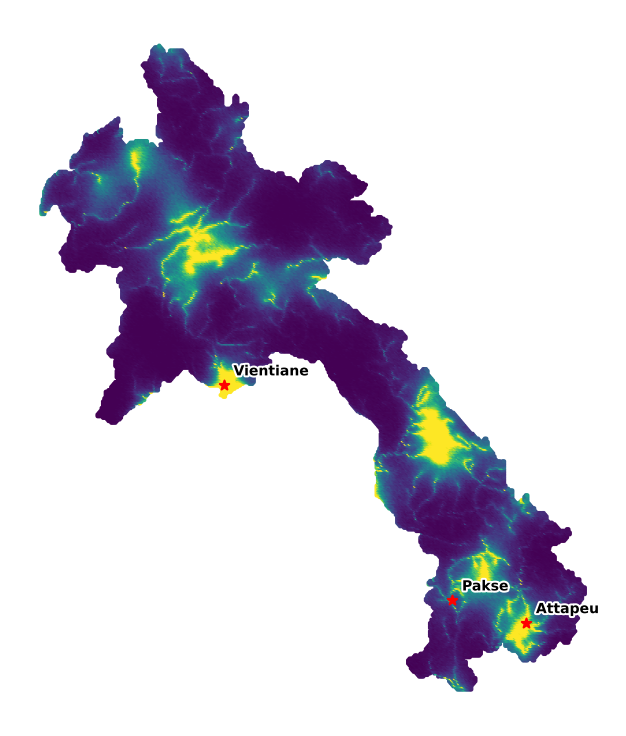

In [10]:
import geopandas as gpd
import matplotlib.patheffects as path_effects
import pickle

# Load pre-computed Laos full model predictions (from 05b_geo_model_laos_neigh.ipynb)
with open(PRETRAINED_IDATA_DIR / "geo_full_lao_2030.pkl", "rb") as f:
    geo_full_lao_idata = pickle.load(f)

# Extract mean event probability and build GeoDataFrame
y_hat_mean = (geo_full_lao_idata
              .posterior_predictive["y_hat"]
              .mean(dim=("chain", "draw"))
              .to_dataframe()
              .reset_index())

df_a = pd.merge(y_hat_mean, laos_point_grid[["lat", "long"]], left_index=True, right_index=True, how="left")
df_a["norm"] = df_a["y_hat"] * 100 / df_a["y_hat"].sum()
df_a = gpd.GeoDataFrame(df_a, geometry=gpd.points_from_xy(df_a["long"], df_a["lat"]), crs="EPSG:4326")

# Build locations GeoDataFrame from cities_loc
locations_df = cities_loc[cities_loc.index.isin(WALL_CITIES)][["lat", "long"]]
locations_df = gpd.GeoDataFrame(locations_df, geometry=gpd.points_from_xy(locations_df["long"], locations_df["lat"]), crs="EPSG:4326")

# Plot
fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=144)
df_a.plot("norm", legend=False, ax=ax, markersize=1.5, vmax=0.01)
locations_df.plot(c="r", marker='*', markersize=25, linestyle='-', ax=ax)

ax.set_xticks([])
ax.set_yticks([])

# Add city names as labels with white border
for idx, row in locations_df.iterrows():
    ax.annotate(
        idx,
        (row["long"], row["lat"]),
        textcoords="offset points",
        xytext=(5, 5),
        ha='left',
        fontsize=7,
        color='black',
        fontweight='bold',
        path_effects=[path_effects.withStroke(linewidth=2, foreground="white")]
    )

fig.savefig(FIGURES_DIR / "loc_lao_map.png", bbox_inches="tight", dpi=144);

# Section 4: Build & Sample Models

For each scenario (base, full wall, intermediate wall), we build the PyMC model and sample posterior predictive distributions. Results are cached to disk.

In [11]:
def build_damage_curve_model(year, event_feat_list, coords_predictions,
                             pred_df_stand_dict, damage_features,
                             ISO_idx_laos, iso_idx_laos, hydro_idx):
    """Build the combined HSGP event + country-level damage PyMC model.

    Event model: HSGP geospatial (from sea_geo_model.idata)
    Damage model: HurdleLogNormal country-level (from dmg_5_2025_usd_new_b.nc)
    Combined: damages_curves = y_hat_damages * event_prob_y_hat
    """
    df_year = pred_df_stand_dict[year]
    n_obs = len(df_year)

    model = pm.Model(coords=coords_predictions)
    with model:
        # ==================== Event Model (HSGP geospatial) ====================
        # Features: 8 standardized features matching 'feature' dim
        X = add_data(
            features=event_feat_list, target=None,
            df=df_year, dims=['obs_idx', 'feature']
        )
        X_gp = pm.Data(
            "X_gp",
            df_year[["lat_centered", "long_centered"]].astype(floatX),
            dims=['obs_idx', 'gp_feature']
        )

        # Country effect — single variable matching 05b event posterior
        country_effect = pm.Flat("country_effect", dims=["ISO"])

        beta = pm.Flat("beta", dims=["feature"])

        # HSGP (Matern 5/2, m=[35,35], c=1.5)
        eta = pm.Flat("eta")
        ell = pm.Flat("ell", dims=["gp_feature"])
        cov_func = eta**2 * pm.gp.cov.Matern52(input_dim=2, ls=ell)
        gp = pm.gp.HSGP(m=[35, 35], c=1.5, cov_func=cov_func)
        gp._X_center = compute_center(
            df_year[["lat_centered", "long_centered"]].values.astype(floatX)
        )
        phi, sqrt_psd = gp.prior_linearized(X=X_gp)
        basis_coeffs = pm.Flat("basis_coeffs", size=gp.n_basis_vectors)
        HSGP_component = pm.Deterministic(
            'HSGP_component', phi @ (basis_coeffs * sqrt_psd), dims=['obs_idx']
        )

        event_features_component = pm.Deterministic(
            'event_features_component', X @ beta, dims=['obs_idx']
        )
        logit_p = pm.Deterministic(
            'logit_p',
            country_effect[ISO_idx_laos] + event_features_component + HSGP_component,
            dims=['obs_idx']
        )
        event_prob_y_hat = pm.Deterministic(
            'event_prob_y_hat', pm.math.invlogit(logit_p), dims=['obs_idx']
        )

        # ==================== Damage Model (HurdleLogNormal) ====================
        # Country-level features matching 'features_damages' dim
        X_damage = pm.Data(
            'X_damage', df_year[damage_features].astype(floatX),
            dims=['obs_idx', 'features_damages']
        )

        # ISO index for damage model (all LAO)
        iso_idx_pt = pm.Data(
            'iso_idx', np.full(n_obs, iso_idx_laos, dtype=int),
            dims=['obs_idx']
        )

        # Latent ISO effect on features
        latent_iso_damage = pm.Flat('latent_iso_damage', dims=['iso', 'features_damages'])

        # Hierarchical country effect for damages
        country_loc_damage = pm.Flat('country_loc_damage', dims=['disaster'])
        country_scale_damage = pm.Flat('country_scale_damage', dims=['disaster'])
        country_offset_damage = pm.Flat('country_offset_damage', dims=['iso', 'disaster'])
        country_effect_damage = pm.Deterministic(
            'country_effect_damage',
            country_loc_damage + country_scale_damage * country_offset_damage,
            dims=['iso', 'disaster']
        )

        beta_damage = pm.Flat('beta_damage', dims=['features_damages', 'disaster'])
        beta_GY_damage = pm.Flat('beta_GY_damage', dims=['features_damages', 'disaster'])
        coef_effect_damage = X_damage @ beta_damage + (latent_iso_damage @ beta_GY_damage)[iso_idx_pt]

        mixture_damage = pm.Flat("mixture_damage", dims=["iso", 'disaster'])

        mu_full = (country_effect_damage + mixture_damage)[iso_idx_pt] + coef_effect_damage

        sigma = pm.Flat('sigma', dims=['disaster'])

        # All grid points are hydro disasters — select hydro column directly
        mu_damage = pm.Deterministic('mu_damage', mu_full[:, hydro_idx], dims=['obs_idx'])

        p_zero_damage = pm.Flat('p_zero_damage', dims=['disaster'])
        y_hat_damages = pm.HurdleLogNormal(
            'y_hat_damages',
            mu=mu_damage,
            sigma=sigma[hydro_idx],
            psi=(1 - p_zero_damage)[hydro_idx],
            observed=np.zeros(n_obs),
            dims=['obs_idx']
        )

        # ==================== Combined Damage Curves ====================
        damages_curves = pm.Deterministic(
            "damages_curves", y_hat_damages * event_prob_y_hat, dims=['obs_idx']
        )

    return model

In [12]:
from pymc.model.transform.optimization import freeze_dims_and_data

def sample_scenario(scenario_name, event_feat_list, cache_prefix):
    """Build models and sample posterior predictive for all years, with caching."""
    idata_dict = {}
    for year in years:
        cache_path = IDATA_DIR / f"{cache_prefix}_{year}.idata"
        if exists(cache_path):
            print(f"  Loading cached {scenario_name} {year}...")
            idata_dict[year] = az.from_netcdf(cache_path)
        else:
            print(f"  Sampling {scenario_name} {year}...")
            model = build_damage_curve_model(
                year, event_feat_list, coords_predictions,
                pred_df_stand_dict, damage_features,
                ISO_idx_laos, iso_idx_laos, hydro_idx
            )
            with freeze_dims_and_data(model):
                idata_dict[year] = pm.sample_posterior_predictive(
                    merged_posteriors, extend_inferencedata=False,
                    compile_kwargs={'mode': 'JAX'},
                    var_names=['damages_curves', 'y_hat_damages',
                               'event_prob_y_hat', 'mu_damage']
                )
            az.to_netcdf(data=idata_dict[year], filename=pathlib.Path(cache_path))
    return idata_dict

In [13]:
# Sample all three scenarios
print("=== Base scenario (no wall) ===")
idata_base = sample_scenario("Base", event_features, "damage_curves_base")

print("\n=== Full wall scenario (max distance) ===")
idata_wall_full = sample_scenario("Full wall", event_features_wall_full, "damage_curves_walls_full")

print("\n=== Intermediate wall scenario (median distance) ===")
idata_wall_median = sample_scenario("Intermediate wall", event_features_wall_median, "damage_curves_walls_median")

=== Base scenario (no wall) ===
  Loading cached Base 2030-01-01...

=== Full wall scenario (max distance) ===
  Loading cached Full wall 2030-01-01...

=== Intermediate wall scenario (median distance) ===
  Loading cached Intermediate wall 2030-01-01...


# Section 5: Extract City Posteriors & Compute Return Years

In [14]:
# Build mapping from point_number to positional obs_idx for each year
point_to_obs_idx = {}
for year in years:
    df_year = pred_df_stand_dict[year]
    point_to_obs_idx[year] = {
        int(pn): pos for pos, pn in enumerate(df_year["point_number"].values)
    }

# Extract city-level posteriors for each scenario
scenario_idatas = {
    "No wall": idata_base,
    "Intermediate wall": idata_wall_median,
    "Full wall": idata_wall_full,
}

city_posteriors = {}  # {city: {scenario: {year: array}}}

for city in WALL_CITIES:
    city_posteriors[city] = {}
    point_num = int(best_loc[city]["point_number"])
    for scenario_name, idata_dict in scenario_idatas.items():
        city_posteriors[city][scenario_name] = {}
        for year in years:
            obs_pos = point_to_obs_idx[year][point_num]
            city_idata = idata_dict[year].sel(obs_idx=obs_pos)
            damages = city_idata.posterior_predictive["damages_curves"].values.ravel()
            city_posteriors[city][scenario_name][year] = damages

In [15]:
def compute_return_year_damages(posterior_samples, return_years=[25, 30, 40, 50]):
    """Compute damages at given return year periods from posterior samples."""
    data = np.sort(posterior_samples)
    n = len(data)
    cdf_vals = np.linspace(1/n, 1, n)
    ppf_func = interpolate.interp1d(cdf_vals, data, bounds_error=False,
                                     fill_value=(data[0], data[-1]))
    results = {}
    for ry in return_years:
        results[f"{ry} RY"] = float(ppf_func(1 - 1/ry))
    return results

# Compute return year damages for all cities, scenarios, years
RETURN_YEARS = [25, 30, 40, 50]

ry_results = []
for city in WALL_CITIES:
    for scenario_name in scenario_idatas.keys():
        for year in years:
            ry_damages = compute_return_year_damages(
                city_posteriors[city][scenario_name][year], RETURN_YEARS
            )
            for ry_label, damage_val in ry_damages.items():
                ry_results.append({
                    "City": city,
                    "Scenario": scenario_name,
                    "Year": year[:4],
                    "Return Period": ry_label,
                    "Damage (USD millions)": damage_val,
                })

ry_df = pd.DataFrame(ry_results)
ry_df.head(12)

,City,Scenario,Year,Return Period,Damage (USD millions)
0,Attapeu,No wall,2030,25 RY,18.344661
1,Attapeu,No wall,2030,30 RY,23.422170
2,Attapeu,No wall,2030,40 RY,36.187104
3,Attapeu,No wall,2030,50 RY,49.213910
4,Attapeu,Intermediate wall,2030,25 RY,8.625158
5,Attapeu,Intermediate wall,2030,30 RY,11.520875
6,Attapeu,Intermediate wall,2030,40 RY,17.118849
7,Attapeu,Intermediate wall,2030,50 RY,22.829291
8,Attapeu,Full wall,2030,25 RY,4.555297
9,Attapeu,Full wall,2030,30 RY,6.083430


# Section 6: Return Year Bar Charts

C:\Users\camil\AppData\Local\Temp\ipykernel_53372\1044930600.py:33: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


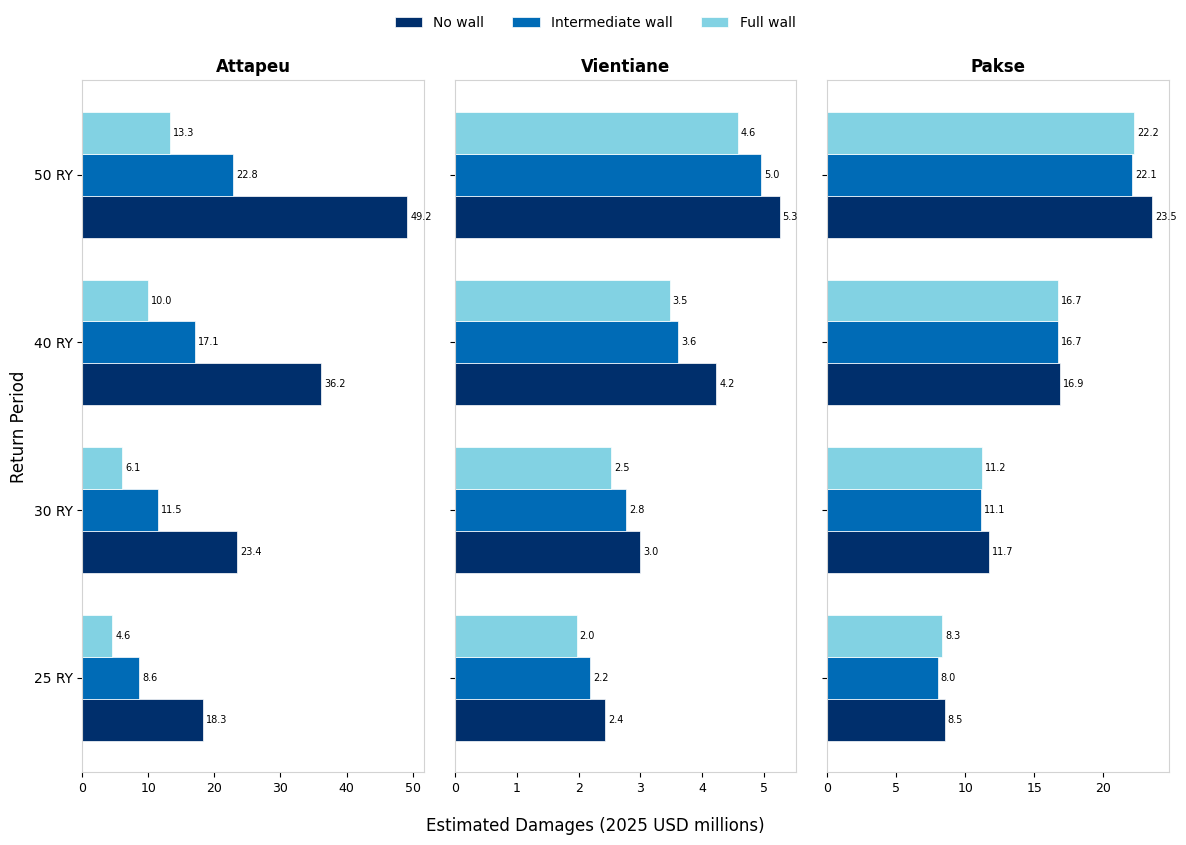

In [16]:
# Horizontal bar chart: all 5 cities, 3 scenarios
FOCUS_YEAR = "2030"

fig, axes = plt.subplots(1, len(WALL_CITIES), figsize=(4 * len(WALL_CITIES), 8), sharey=True)

bar_height = 0.25
return_periods = [f"{ry} RY" for ry in RETURN_YEARS]
y_pos = np.arange(len(return_periods))

for ax, city in zip(axes, WALL_CITIES):
    city_year_df = ry_df.query('City == @city & Year == @FOCUS_YEAR')

    for i, (scenario_name, color) in enumerate(SCENARIO_COLORS.items()):
        scenario_data = city_year_df.query('Scenario == @scenario_name')
        damages = [scenario_data.query('`Return Period` == @rp')["Damage (USD millions)"].values[0]
                   for rp in return_periods]
        bars = ax.barh(y_pos + i * bar_height, damages, bar_height,
                label=scenario_name if city == WALL_CITIES[0] else None,
                color=color, edgecolor='white', linewidth=0.5)
        ax.bar_label(bars, fmt='%.1f', fontsize=7, padding=2)

    ax.set_yticks(y_pos + bar_height)
    ax.set_yticklabels(return_periods, fontsize=10)
    ax.set_title(city, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', labelsize=9)
    for spine in ['bottom', 'top', 'right', 'left']:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color('lightgray')

axes[0].set_ylabel("Return Period", fontsize=12)
fig.supxlabel("Estimated Damages (2025 USD millions)", fontsize=12)
fig.legend(loc='upper center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, 1.05), frameon=False)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'flood_wall_bar_chart_all_cities.png', format='png',
            bbox_inches='tight', dpi=150)
plt.show()

# Section 7: Summary Tables

In [17]:
# Damage reduction table (absolute and percentage)
reduction_rows = []
for _, row in ry_df.iterrows():
    if row["Scenario"] != "No wall":
        base_damage = ry_df.query(
            'City == @row.City & Year == @row.Year & `Return Period` == @row["Return Period"] & Scenario == "No wall"'
        )["Damage (USD millions)"].values[0]
        
        reduction = base_damage - row["Damage (USD millions)"]
        pct_reduction = (reduction / base_damage * 100) if base_damage > 0 else 0
        
        reduction_rows.append({
            "City": row["City"],
            "Scenario": row["Scenario"],
            "Year": row["Year"],
            "Return Period": row["Return Period"],
            "Damage Reduction (USD M)": reduction,
            "Reduction (%)": pct_reduction,
        })

reduction_df = pd.DataFrame(reduction_rows)

# Show reduction for focus year, 50 RY
print(f"Damage reduction at 50 RY — Year {FOCUS_YEAR}")
reduction_50ry = reduction_df.query('`Return Period` == "50 RY" & Year == @FOCUS_YEAR')
pivot_reduction = reduction_50ry.pivot_table(
    index='City', columns='Scenario',
    values=['Damage Reduction (USD M)', 'Reduction (%)'], aggfunc='first'
)

pivot_reduction.round(2).to_csv('data/walls_damage_reduction.csv')
display(pivot_reduction.round(2))

Damage reduction at 50 RY — Year 2030


Damage Reduction (USD M)                   Reduction (%)  \
Scenario                 Full wall Intermediate wall     Full wall   
City                                                                 
Attapeu                      35.91             26.38         72.97   
Pakse                         1.32              1.45          5.59   
Vientiane                     0.68              0.30         12.86   

                             
Scenario  Intermediate wall  
City                         
Attapeu               53.61  
Pakse                  6.15  
Vientiane              5.69

In [18]:
# Full summary table across all return periods for the focus year
print(f"\nFull damage reduction summary — Year {FOCUS_YEAR}")
full_summary = reduction_df.query('Year == @FOCUS_YEAR').pivot_table(
    index=['City', 'Return Period'],
    columns='Scenario',
    values='Damage Reduction (USD M)',
    aggfunc='first'
)

full_summary.round(2).to_csv('data/full_summary.csv')
display(full_summary.round(2))


Full damage reduction summary — Year 2030


Scenario                 Full wall  Intermediate wall
City      Return Period                              
Attapeu   25 RY              13.79               9.72
          30 RY              17.34              11.90
          40 RY              26.22              19.07
          50 RY              35.91              26.38
Pakse     25 RY               0.19               0.50
          30 RY               0.51               0.58
          40 RY               0.18               0.14
          50 RY               1.32               1.45
Vientiane 25 RY               0.47               0.25
          30 RY               0.46               0.22
          40 RY               0.76               0.62
          50 RY               0.68               0.30